# VARM - Project 1

# a. Face detection
> Use one of these algorithms to implement face detection in images collected in real time by a camera (see [1,2] for documentation and [3,4] as examples of implementation).<br>
> [1] - https://docs.opencv.org/master/d6/d0f/group__dnn.html#ga33d1b39b53a891e98a654fdeabba22eb <br>
> [2] - https://github.com/opencv/opencv/wiki/Deep-Learning-in-OpenCV<br>
> [3] - https://docs.opencv.org/3.4/db/d28/tutorial_cascade_classifier.html<br>
> [4] - https://towardsdatascience.com/face-detection-models-which-to-use-and-why-d263e82c302c <br><br>

The code for real-time face detection with camera is on ```a_i_haarcascade.py```, ```a_ii_dnn.py```, ```a_iii_dlib.py``` and ```a_iv_mediapipe.py``` respectively.

## i. Haar Cascade Classifier
> OpenCV “CascadeClassifier” method is based on the algorithm of object detection using Haar feature-based cascade classifiers proposed by Paul Viola and Michael Jones in their paper, “Rapid Object Detection using a Boosted Cascade of Simple Features” in 2001.

The code for real-time face detection with camera is on ```a_i_haarcascade.py```

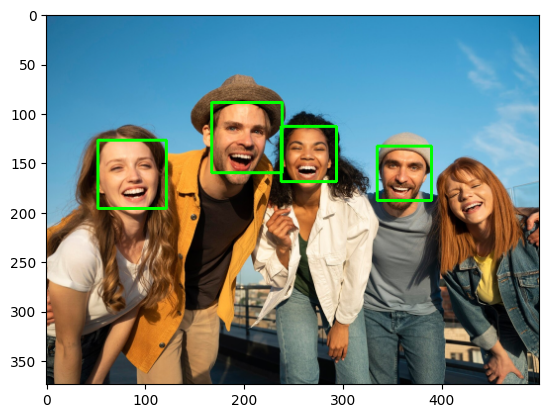

In [1]:
import cv2
import os
import matplotlib.pyplot as plt
from a_i_haarcascade import detect_faces

# load image
img_path = os.path.join(os.getcwd(), 'image.png')
img_orig = cv2.imread(img_path)

# detect faces
img_det = detect_faces(img_orig)
image = cv2.cvtColor(img_det, cv2.COLOR_BGR2RGB) 
plt.imshow(image)

## ii. OpenCV Deep Neural Network module (dnn)
> OpenCV has a deep neural network module and includes pre-trained Convolution Neural Network (CNN) for face detection. This network is based on the ResNet architecture with a Single Shot Detector (SSD) for the detection phase.

The code for real-time face detection with camera is on ```a_ii_dnn.py```

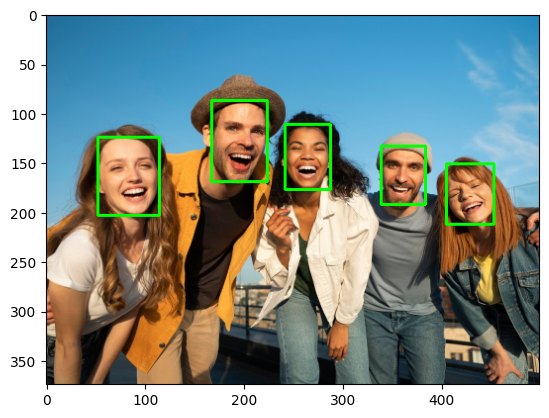

In [2]:
from a_ii_dnn import detect_faces_dnn

# load image
img_path = os.path.join(os.getcwd(), 'image.png')
img_orig = cv2.imread(img_path)

# detect faces
img_det = detect_faces_dnn(img_orig)
image = cv2.cvtColor(img_det, cv2.COLOR_BGR2RGB) 
plt.imshow(image)

## iii. dlib toobox
> Dlib is a toolkit containing machine learning algorithms and tools [5]. It has a set of methods to perform face and facial landmark detection, including up to 68 facial feature points estimation. The face detector uses the Histogram of Oriented Gradients (HOG) feature combined with a linear classifier.<br>
> [5] - http://dlib.net/

The code for real-time face detection with camera is on ```a_iii_dlib.py```

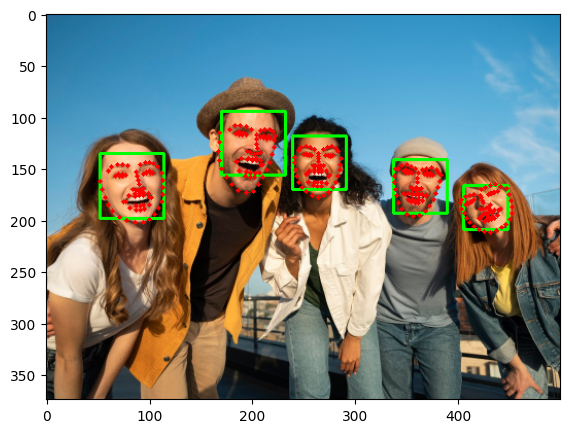

In [3]:
# !brew install cmake boost
# !pip install dlib
#  !conda install -c conda-forge dlib
from a_iii_dlib import detect_faces_dlib

img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# detect faces
image = detect_faces_dlib(img)

# convert from BGR to RGB to show on plt
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) 
plt.figure(figsize=(10,5))
plt.imshow(image)

## iv. Mediapipe
> The MediaPipe Face Detector [6] task detects faces in an image or video. This task can locate faces and facial features within a frame. This task uses a machine learning (ML) model that works with single images or a continuous stream of images. The task outputs face locations, along with the following facial key points: left eye, right eye, nose tip, mouth, left eye tragion, and right eye tragion.<br>
> [6] - https://developers.google.com/mediapipe/solutions/vision/face_detector

The code for real-time face detection with camera is on ```a_iv_mediapipe.py```

2024-04-28 05:31:35.172957: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


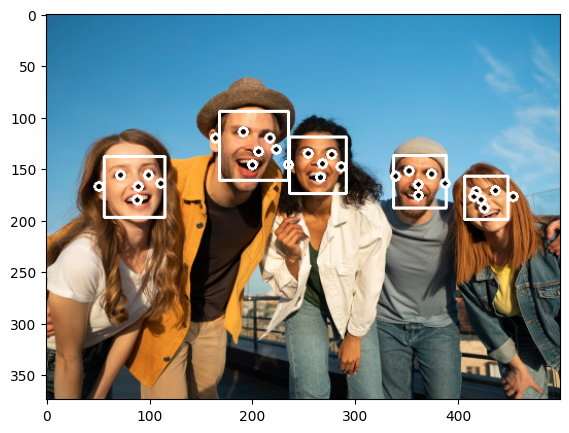

In [4]:
from a_iv_mediapipe import detect_faces_mediapipe

img = cv2.imread("image.png") #img_path)
#gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# detect faces
image = detect_faces_mediapipe(img)

# convert from BGR to RGB to show on plt
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10,5))
plt.imshow(image)
plt.show()


# b. Face Recognition

## i. Face database: 
Perform the acquisition of a face database from the students in the class (7 face images for each student). This set will be used in this project as the training and test sets. It may also be used a face database available on the Internet.

Dataset source: https://www.kaggle.com/datasets/vasukipatel/face-recognition-dataset

  0%|          | 0/13 [00:00<?, ?it/s]

100%|██████████| 13/13 [00:02<00:00,  5.53it/s]


(<matplotlib.image.AxesImage at 0x7fb836c02f40>, 'Virat Kohli')

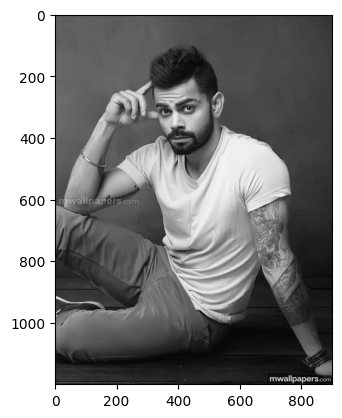

In [5]:
# !pip install tqdm
import os 
import matplotlib.pyplot as plt
from b_i_read_images import read_images

# Prepare the training set consisting of N faces, x1...xN, properly aligned
faces_path = os.path.join(os.getcwd(), 'faces', 'Original Images', 'Original Images')

X, Y, file_names = read_images(faces_path)

plt.imshow(X[0], cmap='gray'), Y[0]

# ii. Face normalization
Proceed with the normalization of the face images from the training set (rotation, scaling, selection) so that the faces comply with the format defined by MPEG-7 recommendation. That is, each face is represented by a monochrome image (256 levels) with 56 rows and 46 columns, with both eyes, right and left, perfectly aligned horizontally, and located in line 24, columns 16 and 31, respectively.

For eye detection, Haar Cascade classifier can also be used with proper XML classifiers files.

https://aanilkayy.medium.com/extract-eyes-in-face-i%CC%87mages-with-dlib-and-face-landmark-points-c45ef480c1



5it [00:01,  2.58it/s]


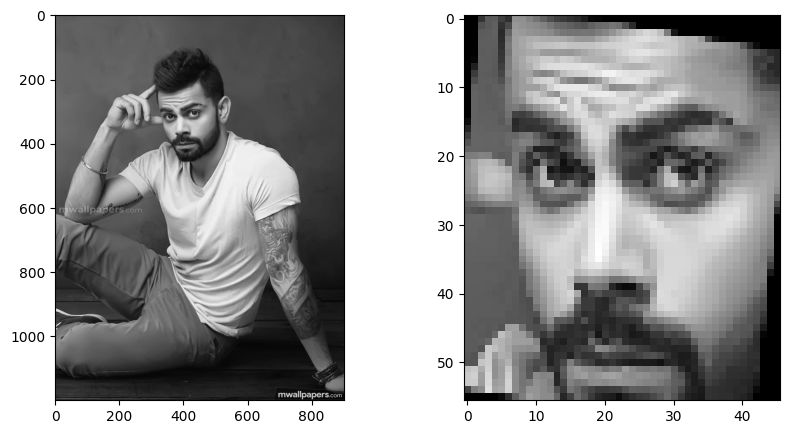

In [19]:
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
from b_ii_normalize import normalize_face


X_norm = []
for i, img in tqdm(enumerate(X[:5])):
    X_norm.append(normalize_face(img))

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(X[0], cmap='gray')
plt.subplot(1,2,2)
plt.imshow(X_norm[0], cmap='gray')

<h3>Load an already normalized dataset for Eigenfaces and Fisherfaces</h3>

(<matplotlib.image.AxesImage at 0x7fb851556b20>, 'Anushka Sharma')

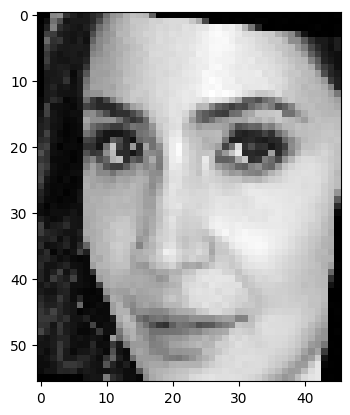

In [7]:

from sklearn.model_selection import train_test_split
import numpy as np
from b_i_read_images import read_images

# Prepare the training set consisting of N faces, x1...xN, properly aligned
#faces_path = os.path.join(os.getcwd(), 'faces', 'Faces', 'Faces')
faces_path = os.path.join(os.getcwd(), 'faces', 'Faces', 'Faces_normalized')

Xn, Yn = [], []
for img_name in os.listdir(faces_path):
    if img_name.endswith('.jpeg'):
        img_path = os.path.join(faces_path, img_name)
        #os.rename(img_path, img_path.replace("jpg", "jpeg")) #was throwing error with jpg

        # read image
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        #img = cv2.resize(img, (56, 46))
        
        Xn.append(img)
        Yn.append(img_path.split('/')[-1].split('_')[0])

Xn, Yn = np.array(Xn), np.array(Yn)

Xtrain, Xtest, ytrain, ytest = train_test_split(Xn, Yn, test_size=0.3, random_state=6)

plt.imshow(Xtrain[0], cmap='gray'), ytrain[0]

plt.imshow(Xtrain[0], cmap='gray'), ytrain[0]

## iii. Using EigenFaces
1. Compute the mean face vector μ (column vector with size of 2576x1) and the transformation matrix 𝑊𝑝𝑐𝑎 (with size of 2576×m), containing the first m eigenfaces (where m can be a number between 10 and 20). Use the procedures presented in the slides of the course. View the m+1 obtained vectors by interpreting them as face images (eigenface) and prove that they form an orthogonal basis.

Faces shape: (78, 2576)
Mean Face shape: (2576, 1)
A element shape: (78,)
A shape: (2576, 78)
R shape: (78, 78)
eigvals shape: (78,) eigvecs shape: (78, 78)
20
Top m indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
V shape: (78, 20)
W shape: (2576, 20)
W_ shape: (2576, 20)
Projections shape: (20, 78)


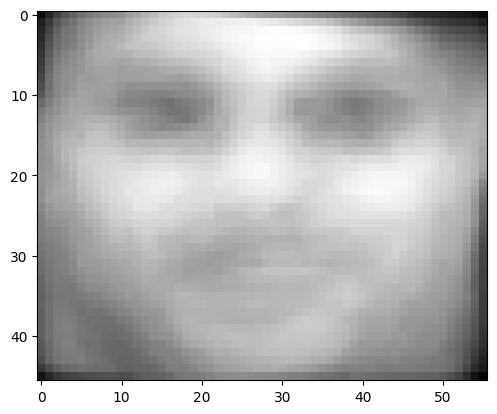

In [8]:
from b_iii_v_eigenfaces_knn import EigenfacesModel

eigenfaces = EigenfacesModel(m = 20) #len(Xn)-1)

eigenfaces.fit(Xtrain, ytrain) # #eigenfaces.fit(X_norm, Yn)

plt.imshow(eigenfaces.mean_face.reshape((46,56)), cmap='gray')


## Predict face using Nearest-Neighbour
i.e., the nearest projection 

centered_image shape: (2576,)
V shape:  (78, 20)
W shape:  (2576, 20)
Test projection shape: (20,)


Text(0.5, 1.0, 'Predicted face - Vijay Deverakonda')

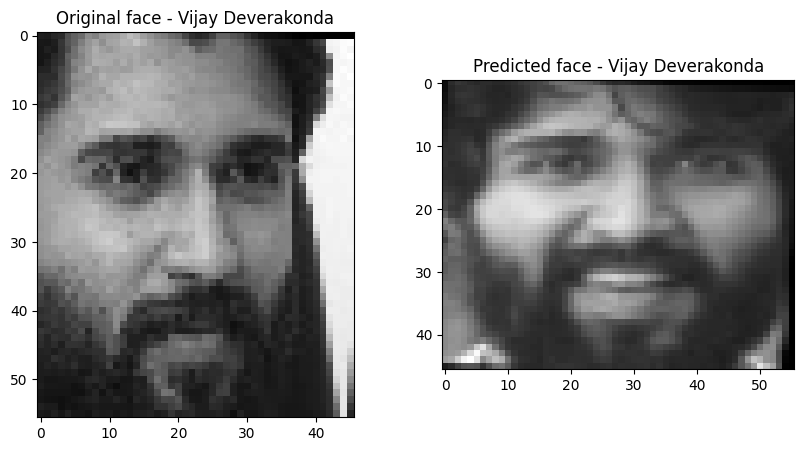

In [9]:
ex = 15
pred_face, pred_idx = eigenfaces.predict(Xtest[ex])

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(Xtest[ex], cmap='gray')
axs[0].set_title(f'Original face - {ytest[ex]}')
axs[1].imshow(pred_face, cmap='gray')
axs[1].set_title(f'Predicted face - {ytrain[pred_idx]}')

## Reconstructed faces and error faces
2. Preform the projection of some of the training set faces on the face subspace and observe their reconstructions. Compute (and view) the error face (difference between the original face and its reconstruction). Show that the error face is orthogonal to the face subspace.

Selected faces: (2576, 3)
V shape: (78, 20)
Selected faces projections shape: (2576, 20)
Resconstructions shape: (2576, 3)
Error faces shape: (2576, 3)
[[ 12.5613095   -3.17727735 -17.67759471 ...  -2.85168146  -3.79474386
   -4.19411576]
 [ 19.86982771  -4.99018032 -28.33734361 ...  -4.76776651  -5.93086817
   -6.54885036]
 [ 22.5525452    0.48135523 -35.16602437 ...  -3.88904559  -0.61240639
   -4.00481394]
 ...
 [ 21.63533168  -5.4609966  -30.55308988 ...  -4.98325264  -6.51442187
   -7.19908472]
 [ 14.21772581  -3.47750342 -20.22364525 ...  -3.31513809  -4.16098638
   -4.65209713]
 [  8.77314074  -2.29816941 -12.54226595 ...  -2.18578912  -2.70532371
   -2.93032188]]
Orthogonality check: False


Text(0.5, 1.0, 'Reconstructed face 3')

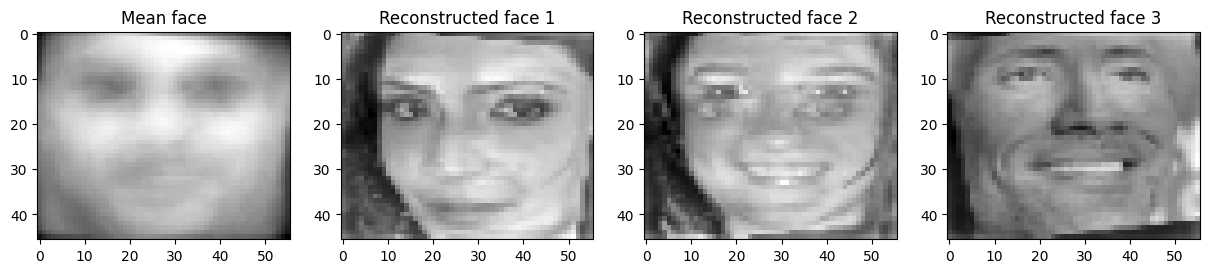

In [10]:
error_faces, reconstructions = eigenfaces.get_error_faces_and_reconstructions([0, 1, 2])

fig, axs = plt.subplots(1, 4, figsize=(15, 5))
axs[0].imshow(eigenfaces.mean_face.reshape(46,56), cmap='gray')
axs[0].set_title('Mean face')
axs[1].imshow(reconstructions[:, 0].reshape((46,56)).real, cmap='gray')
axs[1].set_title('Reconstructed face 1')
axs[2].imshow(reconstructions[:, 1].reshape((46,56)).real, cmap='gray')
axs[2].set_title('Reconstructed face 2')
axs[3].imshow(reconstructions[:, 2].reshape((46,56)).real, cmap='gray')
axs[3].set_title('Reconstructed face 3')


Text(0.5, 1.0, 'Error face 3')

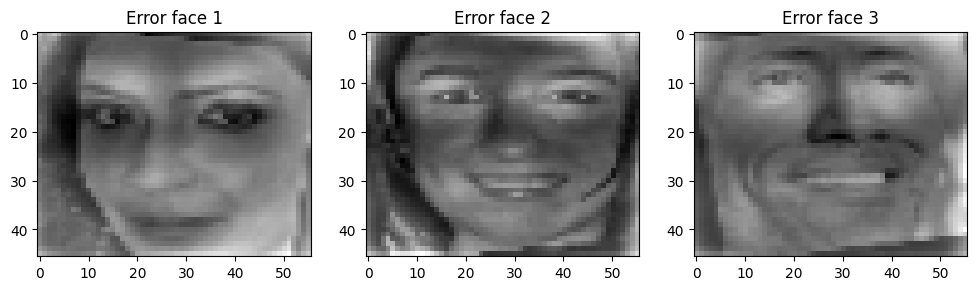

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(12, 5))
axs[0].imshow(error_faces[:,0].reshape((46,56)).real, cmap='gray')
axs[0].set_title('Error face 1')
axs[1].imshow(error_faces[:,1].reshape((46,56)).real, cmap='gray')
axs[1].set_title('Error face 2')
axs[2].imshow(error_faces[:,2].reshape((46,56)).real, cmap='gray')
axs[2].set_title('Error face 3')

# Fisherfaces

Faces shape: (78, 2576)
EigenfacesModel
Faces shape: (78, 2576)
Mean Face shape: (2576, 1)
A element shape: (78,)
A shape: (2576, 78)
R shape: (78, 78)
eigvals shape: (78,) eigvecs shape: (78, 78)
20
Top m indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
V shape: (78, 20)
W shape: (2576, 20)
W_ shape: (2576, 20)
Projections shape: (20, 78)
Mean Face shape: (2576, 1)
A shape: (2576, 78)
projections shape: (12, 78)


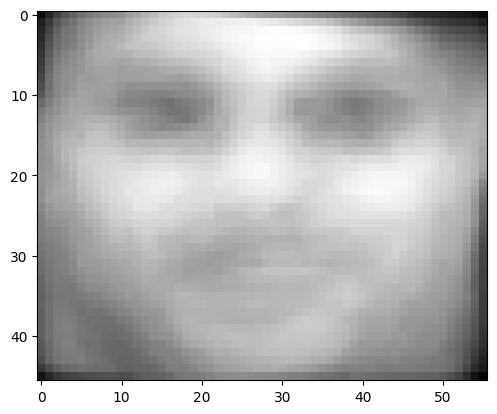

In [12]:
from b_iv_v_fisherfaces_knn import FisherfacesModel

fisherfaces = FisherfacesModel(m = 20) 

fisherfaces.fit(Xtrain, ytrain) 

plt.imshow(fisherfaces.mean_face.reshape((46,56)), cmap='gray')

## Predict face using Nearest-Neighbour
i.e., the nearest projection 

centered_image shape: (2576,)
Wfisher shape:  (2576, 12)
Test projection shape: (12,)


Text(0.5, 1.0, 'Predicted face - Dwayne Johnson')

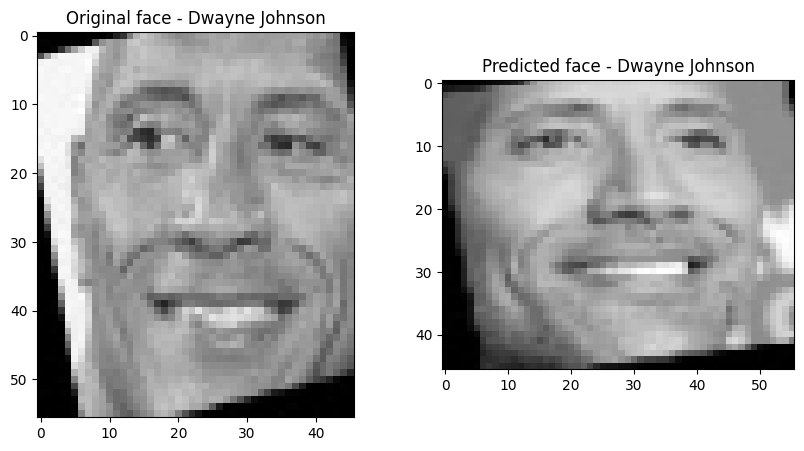

In [13]:
ex = 12
pred_face, pred_idx = fisherfaces.predict(Xtest[ex])

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(Xtest[ex], cmap='gray')
axs[0].set_title(f'Original face - {ytest[ex]}')
axs[1].imshow(pred_face, cmap='gray')
axs[1].set_title(f'Predicted face - {ytrain[pred_idx]}')

## Reconstructed faces and error faces
2. Preform the projection of some of the training set faces on the face subspace and observe their reconstructions. Compute (and view) the error face (difference between the original face and its reconstruction). Show that the error face is orthogonal to the face subspace.

Selected faces: (2576, 3)
V shape: (2576, 12)
Selected faces projections shape: (12, 2576)
Resconstructions shape: (2576, 3)
Error faces shape: (2576, 3)


Text(0.5, 1.0, 'Reconstructed face 3')

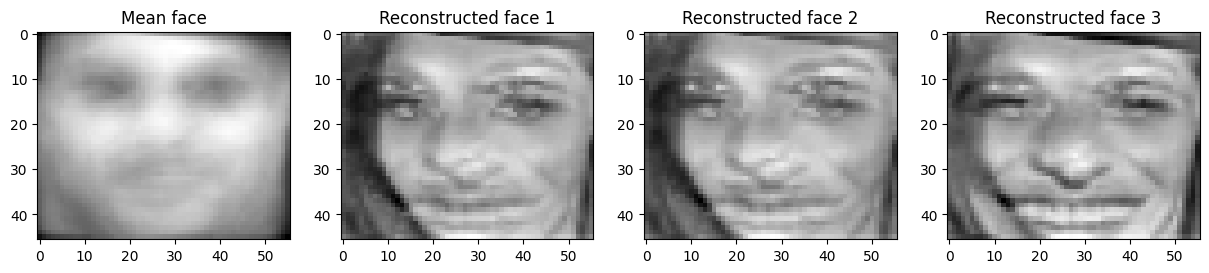

In [14]:
error_faces, reconstructions = fisherfaces.get_error_faces_and_reconstructions()

fig, axs = plt.subplots(1, 4, figsize=(15, 5))
axs[0].imshow(fisherfaces.mean_face.reshape(46,56), cmap='gray')
axs[0].set_title('Mean face')
axs[1].imshow(reconstructions[:, 0].reshape((46,56)).real, cmap='gray')
axs[1].set_title('Reconstructed face 1')
axs[2].imshow(reconstructions[:, 1].reshape((46,56)).real, cmap='gray')
axs[2].set_title('Reconstructed face 2')
axs[3].imshow(reconstructions[:, 2].reshape((46,56)).real, cmap='gray')
axs[3].set_title('Reconstructed face 3')

Text(0.5, 1.0, 'Error face 3')

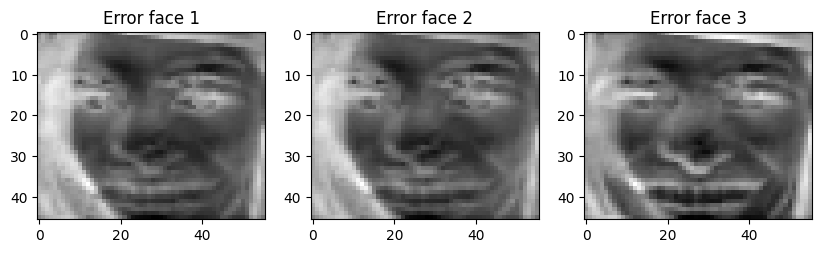

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(10, 5))
axs[0].imshow(error_faces[:,0].reshape((46,56)).real, cmap='gray')
axs[0].set_title('Error face 1')
axs[1].imshow(error_faces[:,1].reshape((46,56)).real, cmap='gray')
axs[1].set_title('Error face 2')
axs[2].imshow(error_faces[:,2].reshape((46,56)).real, cmap='gray')
axs[2].set_title('Error face 3')

# c. Combine real and virtual objects.
## i. Virtual object normalization

Based on the alignment of section b.ii, normalize the virtual object that is intended to be superimposed on the identified face, for example, a hat, glasses, or other object of your choice. Use different objects for different faces/persons.

## ii. Adding with mask
Add to the image, using a mask.


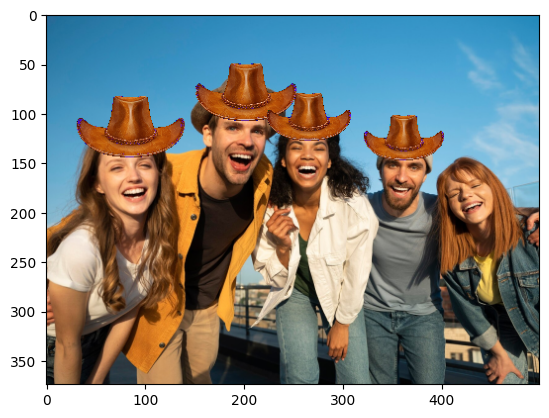

In [25]:

from c_i_ii_mask import superimpose_hat, superimpose_glasses


# initialize pre-trained classifier
classifier = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

# Detect faces in the grayscale image
image = cv2.imread("image.png") #cv2.resize(Xtrain[11], (56,46))
faces = classifier.detectMultiScale(image, scaleFactor=1.3, minNeighbors=5)

for (x, y, w, h) in faces:
    # limit face square
    face_square = cv2.resize(image[y:y+h, x:x+w], (46, 56))

    # auperimpose hat
    image = superimpose_hat(image, x, y, w, h)

# convert from BGR to RGB to show on plt
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the color frame with detected faces
plt.imshow(image)



(54, 128, 3)
(54, 128, 3)
(54, 128, 3)
(54, 128, 3)


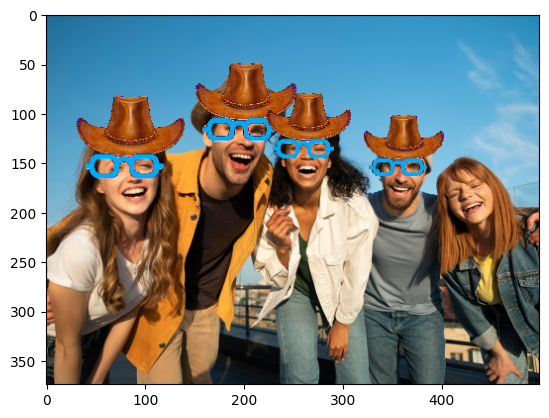

In [22]:

# Detect faces in the grayscale image
image = cv2.imread("image.png") #cv2.resize(Xtrain[11], (56,46))
faces = classifier.detectMultiScale(image, scaleFactor=1.3, minNeighbors=5)

for (x, y, w, h) in faces:
    # limit face square
    face_square = cv2.resize(image[y:y+h, x:x+w], (46, 56))

    # auperimpose hat
    image = superimpose_hat(image, x, y, w, h)
    image = superimpose_glasses(image, x, y, w, h, "blue-glasses")

# convert from BGR to RGB to show on plt
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the color frame with detected faces
plt.imshow(image)